<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/GenetskiAlgoritamDom1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

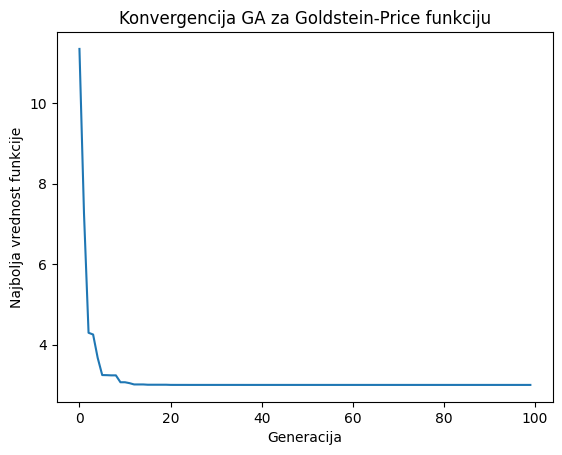

Najbolje rešenje: x = 3.0518043793392735e-05, y = -0.9999847409781033, f(x, y) = 3.000000234694767


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Goldstein-Price funkcija
def goldstein_price(x, y):
    term1 = 1 + (x + y + 1)**2 * (19 - 14*x + 3*x**2 - 14*y + 6*x*y + 3*y**2)
    term2 = 30 + (2*x - 3*y)**2 * (18 - 32*x + 12*x**2 + 48*y - 36*x*y + 27*y**2)
    return term1 * term2

# Pretvaranje binarnog hromozoma u realnu vrednost
def decode(binary_str, bounds, num_bits):
    decimal = int(binary_str, 2)
    min_val, max_val = bounds
    return min_val + (max_val - min_val) * decimal / (2**num_bits - 1)

# Generisanje inicijalne populacije
def generate_population(size, num_bits):
    return ["".join(random.choice("01") for _ in range(2 * num_bits)) for _ in range(size)]

# Evaluacija populacije
def evaluate_population(population, bounds, num_bits):
    fitness = []
    for chrom in population:
        x = decode(chrom[:num_bits], bounds, num_bits)
        y = decode(chrom[num_bits:], bounds, num_bits)
        fitness.append(1 / goldstein_price(x, y))  # Minimization => Inverse fitness
    return np.array(fitness)

# Ruletska selekcija
def roulette_wheel_selection(population, fitness):
    total_fitness = np.sum(fitness)
    probabilities = fitness / total_fitness
    selected = np.random.choice(population, size=len(population), p=probabilities)
    return selected

# Ukrštanje (jednopoložajno)
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    return parent1[:point] + parent2[point:], parent2[:point] + parent1[point:]

# Mutacija (bit-flip)
def mutate(chromosome, mutation_rate):
    return "".join(bit if random.random() > mutation_rate else str(1 - int(bit)) for bit in chromosome)

# Inverzija (obrće deo hromozoma)
def inversion(chromosome):
    i, j = sorted(random.sample(range(len(chromosome)), 2))
    return chromosome[:i] + chromosome[i:j][::-1] + chromosome[j:]

# Glavna funkcija GA
def genetic_algorithm(pop_size=50, num_bits=16, bounds=(-2, 2), mutation_rate=0.01, generations=100):
    population = generate_population(pop_size, num_bits)
    best_solution = None
    best_fitness = float('-inf')
    best_values = []

    for _ in range(generations):
        fitness = evaluate_population(population, bounds, num_bits)
        best_idx = np.argmax(fitness)

        if fitness[best_idx] > best_fitness:
            best_fitness = fitness[best_idx]
            best_solution = population[best_idx]

        best_values.append(1 / best_fitness)  # Store best function value over generations
        selected = roulette_wheel_selection(population, fitness)
        new_population = []

        for i in range(0, pop_size, 2):
            p1, p2 = selected[i], selected[i+1]
            c1, c2 = crossover(p1, p2)
            c1, c2 = mutate(c1, mutation_rate), mutate(c2, mutation_rate)
            c1, c2 = inversion(c1), inversion(c2)
            new_population.extend([c1, c2])

        population = new_population

    # Dekodovanje najboljeg rešenja
    x_best = decode(best_solution[:num_bits], bounds, num_bits)
    y_best = decode(best_solution[num_bits:], bounds, num_bits)
    best_value = goldstein_price(x_best, y_best)

    # Prikaz rezultata
    plt.plot(best_values)
    plt.xlabel("Generacija")
    plt.ylabel("Najbolja vrednost funkcije")
    plt.title("Konvergencija GA za Goldstein-Price funkciju")
    plt.show()

    return x_best, y_best, best_value

# Pokretanje algoritma
best_x, best_y, best_value = genetic_algorithm()
print(f'Najbolje rešenje: x = {best_x}, y = {best_y}, f(x, y) = {best_value}')